In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Flow Examples (Stokes Equations Solutions)</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *

---

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Exchanger Device</h3>
</div>

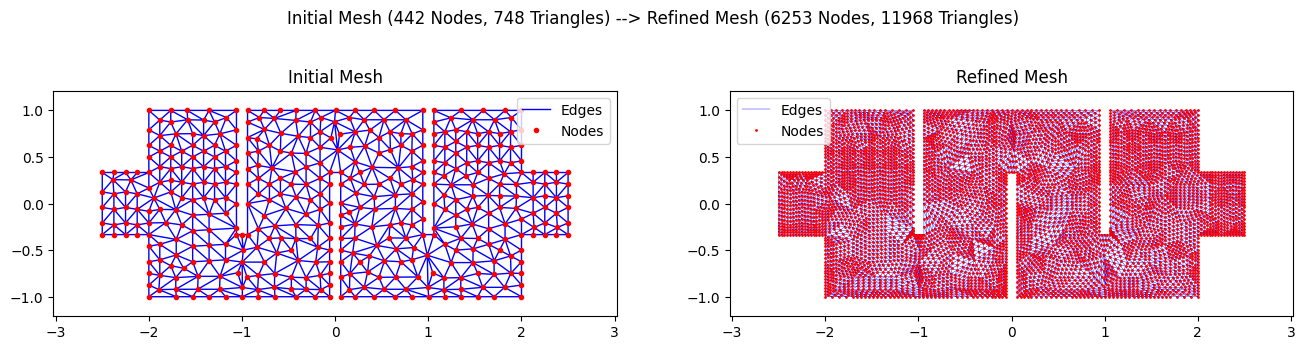

In [15]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=2, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [16]:
def compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-17

    xmin = p_fine[:, 0].min()
    xmax = p_fine[:, 0].max()

    inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
    outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

    # Extract all physical boundary nodes from edge flags
    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])

    # Exclude inlet and outlet from solid walls
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    lf_x[inlet_idx] = -1.0  

    A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=0.01)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    F = calculate_F(A, Bx, By, (lf_x, lf_y))
    K = calculate_Saddle_point_K(A, Bx, By)

    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))
    K = K.tolil()

    for i in dirichlet_nodes:
        # X-velocity tracks
        K[i, :] = 0.0
        K[i, i] = 1.0
        F[i] = 0.0  

        # Y-velocity tracks (shifted by Nv)
        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy] = 0.0  

    is_outlet_p = (np.abs(p_coarse[:, 0] - xmax) < eps)
    p_ref_idx = np.where(is_outlet_p)[0]
    p_ref = p_ref_idx[0]
    p_row = 2 * Nv + p_ref

    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0

    print("Solving lifted system...")
    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        print("Warning: NaNs detected!")

    u0_x = sol[:Nv]
    u0_y = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    ux = u0_x + lf_x
    uy = u0_y + lf_y

    div = Bx @ ux + By @ uy
    print("||div|| =", np.linalg.norm(div))
    print("max div =", np.max(np.abs(div)))

    return ux, uy, pressure

In [17]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse)

Solving lifted system...
||div|| = 0.23846434785900023
max div = 0.06076388526707888


In [18]:
save_simulation_data(p_fine, e_fine, t_fine, 
                     p_coarse, e_coarse, t_coarse, 
                     ux, uy, p_sol,
                     name='Exchanger_device')

Simulation 'Exchanger_device' data saved.


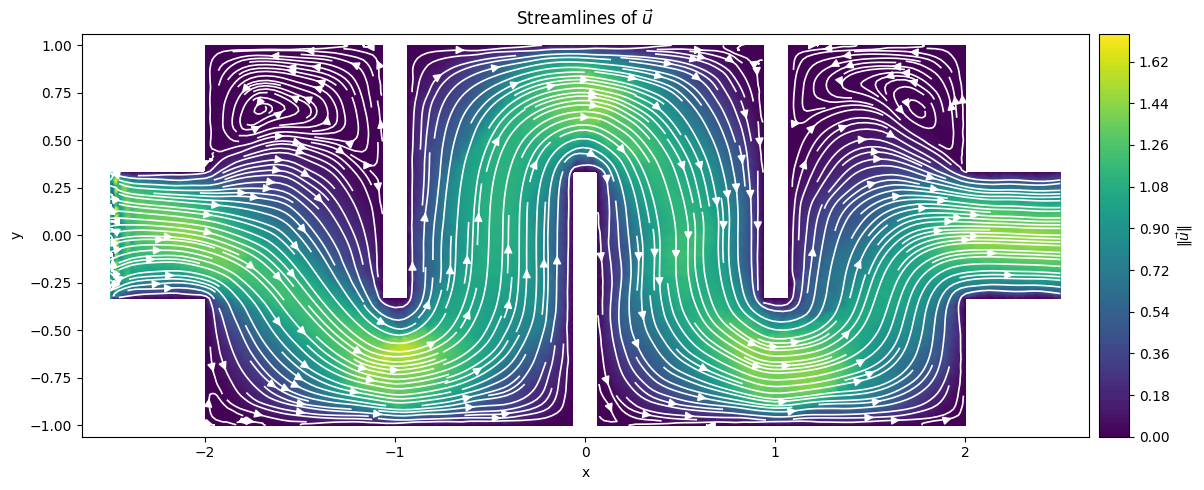

In [19]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 grid_num=(500,500),
                 figsize=(15,5),
                 density=3.7)

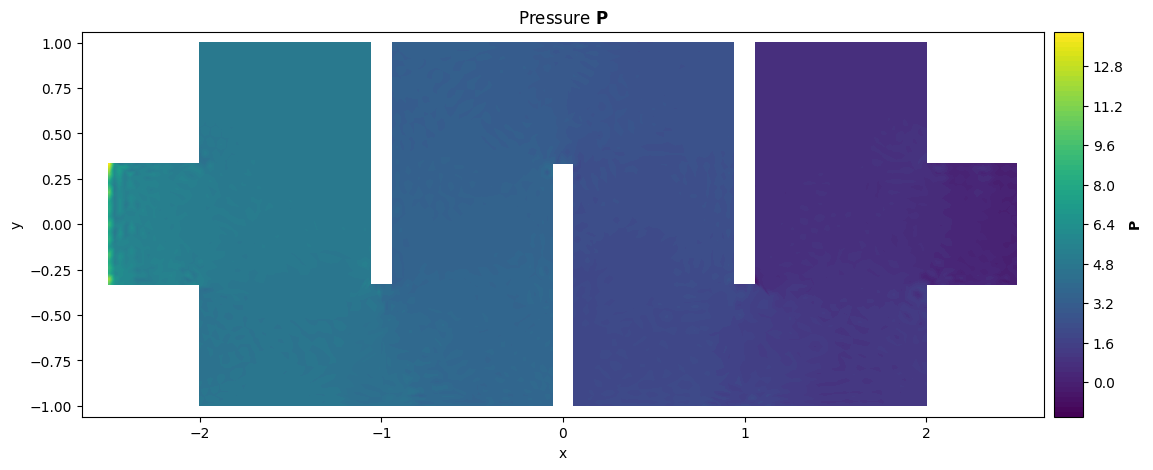

In [20]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))

<div style="background-color: #7ac4ef; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Laminar Flow Past a Backstep</h3>
</div>

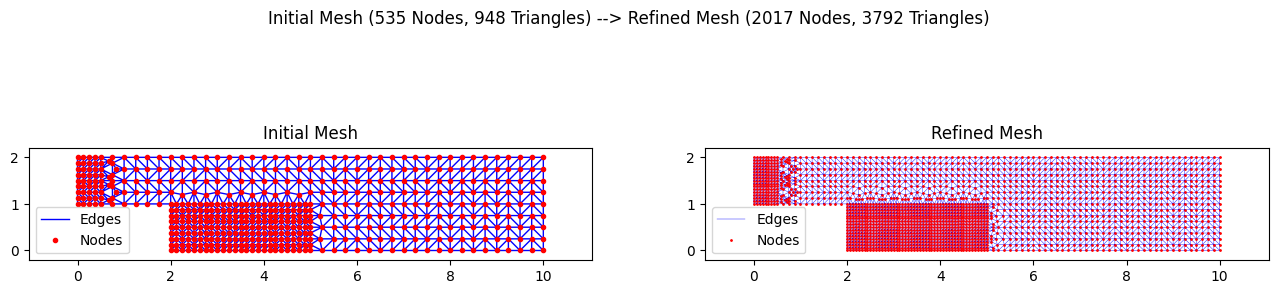

In [9]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/Backstep_mesh_data.npz', num_of_refinements=1, 
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [10]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse)

Solving lifted system...
||div|| = 0.35386025444480934
max div = 0.08333336313565597


In [11]:
save_simulation_data(p_fine, e_fine, t_fine, 
                     p_coarse, e_coarse, t_coarse, 
                     ux, uy, p_sol,
                     name='Backstep')

Simulation 'Backstep' data saved.


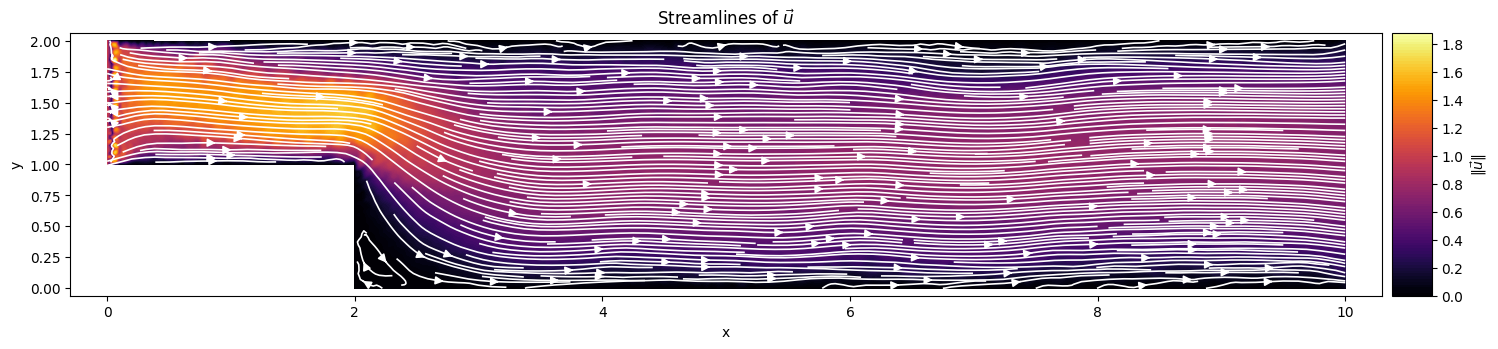

In [12]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 figsize=(15,5),
                 cmap='inferno',
                 levels=100,
                 grid_num=(1500,500),
                 density=2.7)

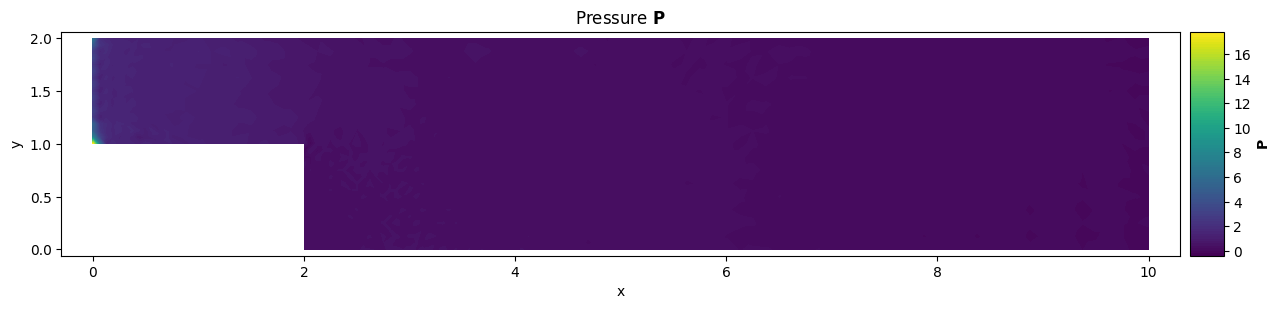

In [13]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))